#### Import

In [1]:
import sys
import torch
sys.path.insert(0, '..')
from src.gnn.seed import set_seed
from src.gnn.data import load_and_preprocess_data
from src.gnn.training import compute_class_weights, train_with_early_stopping, print_test_evaluation
from src.gnn.visualization import plot_learning_curves
from src.gnn.losses import FocalLoss
from src.gnn.models import GAT

#### Seed

In [2]:
set_seed(42)

#### Load data

In [3]:
data, device = load_and_preprocess_data('../data/processed/pyg_data.pt', undirected=False)

Device: cpu
Data(x=[203769, 165], edge_index=[2, 234355], y=[203769], train_mask=[203769], val_mask=[203769], test_mask=[203769])


#### Define model

In [4]:
model = GAT(
    in_channels=data.x.shape[1], 
    hidden_channels=64,
    out_channels=2, 
    heads=2,      
    dropout=0.5
).to(device)

print(model)

GAT(
  (conv1): GATv2Conv(165, 64, heads=2)
  (conv2): GATv2Conv(128, 2, heads=1)
)


#### Focal Loss and Optimizer

In [5]:
weight = compute_class_weights(data, device)

criterion = FocalLoss(gamma=1.0) 
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

Class weights: licit=1.00, illicit=2.86


#### Training loop

In [6]:
history = train_with_early_stopping(
    model=model, 
    data=data, 
    optimizer=optimizer, 
    criterion=criterion, 
    save_path='../saved_models/gat_best.pt', 
    num_epochs=200, 
    patience=20,
    clip_grad_norm=1.0 
)

Epoch 001: Train Loss=0.5817, Train F1=0.0759, Val F1=0.3486, Gap=-0.2726
Epoch 002: Train Loss=0.3347, Train F1=0.3715, Val F1=0.4256, Gap=-0.0541
Epoch 003: Train Loss=0.2244, Train F1=0.4780, Val F1=0.3793, Gap=0.0987
Epoch 004: Train Loss=0.2114, Train F1=0.5142, Val F1=0.3980, Gap=0.1162
Epoch 005: Train Loss=0.1874, Train F1=0.5409, Val F1=0.4552, Gap=0.0857
Epoch 006: Train Loss=0.1826, Train F1=0.5349, Val F1=0.5055, Gap=0.0294
Epoch 007: Train Loss=0.1733, Train F1=0.5514, Val F1=0.4937, Gap=0.0577
Epoch 008: Train Loss=0.1694, Train F1=0.6228, Val F1=0.5169, Gap=0.1059
Epoch 009: Train Loss=0.1615, Train F1=0.6145, Val F1=0.5250, Gap=0.0896
Epoch 010: Train Loss=0.1566, Train F1=0.6082, Val F1=0.5173, Gap=0.0909
Epoch 011: Train Loss=0.1522, Train F1=0.6226, Val F1=0.5238, Gap=0.0988
Epoch 012: Train Loss=0.1441, Train F1=0.6282, Val F1=0.5424, Gap=0.0858
Epoch 013: Train Loss=0.1376, Train F1=0.6375, Val F1=0.5649, Gap=0.0726
Epoch 014: Train Loss=0.1337, Train F1=0.6452, Va

#### Learning curve

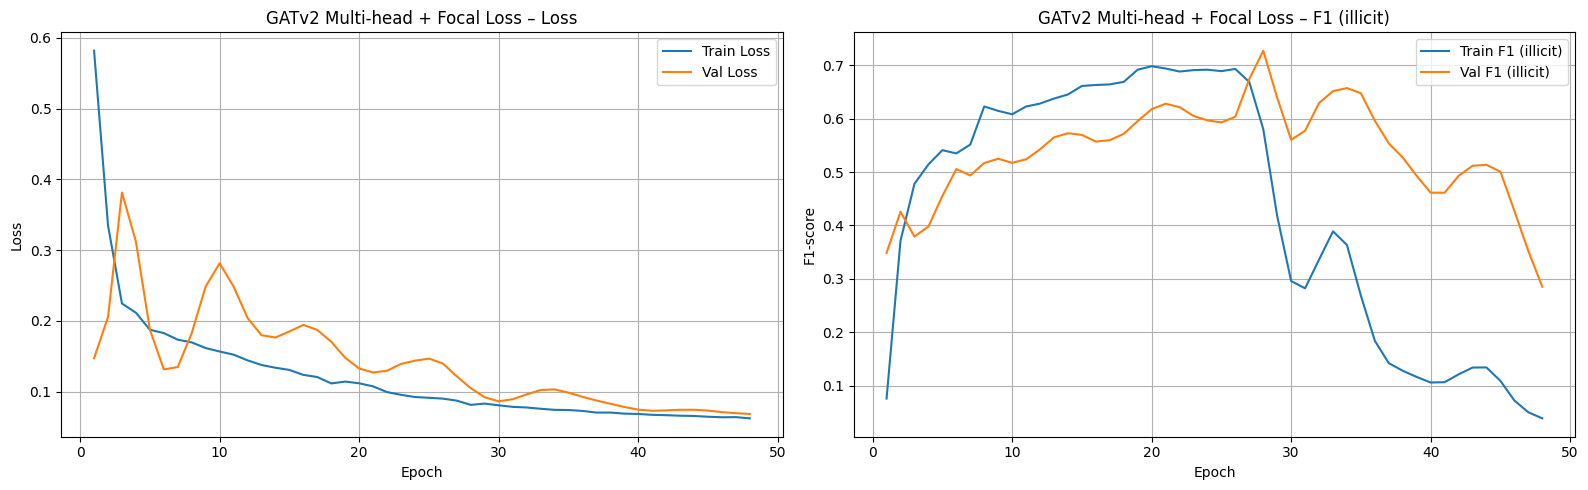

In [7]:
plot_learning_curves(history, model_name="GATv2 Multi-head + Focal Loss")

#### Test evaluation

In [8]:
model.load_state_dict(torch.load('../saved_models/gat_best.pt'))
print_test_evaluation(model, data, criterion, label="GAT Test")

 GAT Test Set Evaluation
  Loss          : 0.1227
  Accuracy      : 0.8905
  Precision(ill): 0.3171
  Recall(ill)   : 0.5946
  F1(illicit)   : 0.4136
  F1(macro)     : 0.6766
  AUC-PR        : 0.3565
Classification Report:
              precision    recall  f1-score   support

   Licit (0)     0.9700    0.9110    0.9396     15587
 Illicit (1)     0.3171    0.5946    0.4136      1083

    accuracy                         0.8905     16670
   macro avg     0.6435    0.7528    0.6766     16670
weighted avg     0.9276    0.8905    0.9054     16670

Confusion Matrix:
[[14200  1387]
 [  439   644]]
